# ELSA Depression Prediction
### MSc AI & Health — Group Assignment

**Goal:** Use Wave 6 features to predict whether a participant has depression at Wave 7.

**Target variable:** `hepsyde` — *Psychiatric problem: depression* (0 = not mentioned, 1 = mentioned)

**Models:** Random Forest + XGBoost (compared side by side)

## Cell 1 — Install & Import Libraries

In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Cell 2 — Load the Data

In [2]:
w6 = pd.read_csv('ELSA_Dataset/ELSA_Clean/clean_wave_6_elsa_data_v2.csv')
w7 = pd.read_csv('ELSA_Dataset/ELSA_Clean/clean_wave_7_elsa_data.csv')

print(f'Wave 6: {w6.shape[0]:,} participants, {w6.shape[1]} columns')
print(f'Wave 7: {w7.shape[0]:,} participants, {w7.shape[1]} columns')

print('\nWave 6 columns:', list(w6.columns))
print('\nWave 7 columns:', list(w7.columns))

Wave 6: 10,601 participants, 39 columns
Wave 7: 9,666 participants, 39 columns

Wave 6 columns: ['idauniq', 'perid', 'DiSex', 'DiMar', 'HeAge', 'DiMaedu', 'MiLive', 'WhoSo1', 'WhoSo2', 'WhoSo3', 'WhoSo4', 'WhoSo5', 'Hehelf', 'Heill', 'Helim', 'HePain', 'HeSmk', 'HeActa', 'HeActb', 'HeActc', 'Heiqa', 'Heiqb', 'Heiqc', 'Heiqd', 'Heiqe', 'hepsyde', 'hepsyan', 'hepsyem', 'hepsyps', 'hepsymo', 'hepsyma', 'PScedA', 'PScedB', 'PScedC', 'PScedD', 'PScedE', 'PScedF', 'PScedG', 'PScedH']

Wave 7 columns: ['idauniq', 'perid', 'DiSex', 'DiMar', 'HeAge', 'DiMaedu', 'MiLive', 'WhoSo1', 'WhoSo2', 'WhoSo3', 'WhoSo4', 'WhoSo5', 'Hehelf', 'Heill', 'Helim', 'HePain', 'HeSmk', 'HeActa', 'HeActb', 'HeActc', 'Heiqa', 'Heiqb', 'Heiqc', 'Heiqd', 'Heiqe', 'hepsyde', 'hepsyan', 'hepsyem', 'hepsyps', 'hepsymo', 'hepsyma', 'PScedA', 'PScedB', 'PScedC', 'PScedD', 'PScedE', 'PScedF', 'PScedG', 'PScedH']


## Cell 3 — Build the Target Variable (Wave 7 Depression)

`hepsyde` = 1 means the participant mentioned depression as a psychiatric problem at Wave 7.  
We treat this as our binary prediction target.

In [3]:
# ELSA uses negative values as missing/not applicable codes
MISSING_CODES = [-1, -2, -3, -4, -8, -9]

# Extract target from wave 7
w7_target = w7[['idauniq', 'hepsyde']].copy()
w7_target['hepsyde'] = w7_target['hepsyde'].replace(MISSING_CODES, np.nan)

# Keep only participants with a valid depression label
w7_target = w7_target.dropna(subset=['hepsyde'])
w7_target['depressed_w7'] = w7_target['hepsyde'].astype(int)

print(f'Wave 7 participants with valid depression label: {len(w7_target):,}')
print(f"\nClass balance:")
print(f"  Depressed (hepsyde=1): {w7_target['depressed_w7'].sum()} ({w7_target['depressed_w7'].mean()*100:.1f}%)")
print(f"  Not depressed (hepsyde=0): {(w7_target['depressed_w7']==0).sum()} ({(1-w7_target['depressed_w7'].mean())*100:.1f}%)")

Wave 7 participants with valid depression label: 1,011

Class balance:
  Depressed (hepsyde=1): 692 (68.4%)
  Not depressed (hepsyde=0): 319 (31.6%)


## Cell 4 — Select Features from Wave 6

We use Wave 6 data to predict Wave 7 outcomes — this is a **longitudinal prediction** setup.

Feature categories:
- **Sociodemographic:** sex, marital status, education
- **Social contact:** WhoSo1–5 (who participant socialises with)
- **Physical health:** self-rated health, illness, pain, smoking, activity
- **Prior mental health:** hepsyde, hepsyan etc. from Wave 6 (strongest predictors)

In [4]:
FEATURE_COLS = [
    # Sociodemographic
    'DiSex',     # Sex (1=male, 2=female)
    'DiMar',     # Marital status
    'DiMaedu',   # Education level

    # Social contact indicators
    'WhoSo1', 'WhoSo2', 'WhoSo3', 'WhoSo4', 'WhoSo5',

    # Physical health
    'Hehelf',    # Self-rated health (1=excellent, 5=poor)
    'Heill',     # Long-standing illness
    'Helim',     # Health limits daily activities
    'HePain',    # Pain
    'HeSmk',     # Smoking
    'HeActa',    # Vigorous physical activity
    'HeActb',    # Moderate physical activity
    'HeActc',    # Mild physical activity

    # Prior wave mental health (Wave 6)
    'hepsyde',   # Had depression at wave 6
    'hepsyan',   # Anxiety at wave 6
    'hepsyem',   # Emotional problems at wave 6
    'hepsyps',   # Positive mental health
    'hepsymo',   # Morale
    'hepsyma',   # Mastery/control
    'PScedA',    # Felt depressed
    'PScedB',    # Everything was an effort
    'PScedC',    # Sleep was restless
    'PScedD',    # Was happy (reverse scored)
    'PScedE',    # Felt lonely
    'PScedF',    # Enjoyed life (reverse scored)
    'PScedG',    # Felt sad
    'PScedH',    # Couldn't get going
]

w6_features = w6[['idauniq'] + FEATURE_COLS].copy()

# Replace all ELSA missing codes with NaN
for col in FEATURE_COLS:
    w6_features[col] = w6_features[col].replace(MISSING_CODES, np.nan)

print(f'Wave 6 features extracted: {len(FEATURE_COLS)} features')
print(f'\nMissing data summary (% missing):')
missing_pct = (w6_features[FEATURE_COLS].isnull().sum() / len(w6_features) * 100).round(1)
print(missing_pct[missing_pct > 0].to_string())

Wave 6 features extracted: 30 features

Missing data summary (% missing):
DiMaedu     9.7
Hehelf      5.9
Heill       0.1
Helim      45.5
HePain      5.9
HeSmk      56.7
hepsyde    89.7
hepsyan    89.7
hepsyem    89.7
hepsyps    89.7
hepsymo    89.7
hepsyma    89.7
PScedA      6.5
PScedB      6.5
PScedC      6.4
PScedD      6.6
PScedE      6.5
PScedF      6.7
PScedG      6.6
PScedH      6.5


## Cell 5 — Merge Waves & Final Dataset

In [5]:
# Inner join: keep only participants present in both waves with a valid target
df = pd.merge(
    w6_features,
    w7_target[['idauniq', 'depressed_w7']],
    on='idauniq',
    how='inner'
)

print(f'Final dataset: {len(df):,} participants')
print(f'Depressed at Wave 7: {df["depressed_w7"].sum()} ({df["depressed_w7"].mean()*100:.1f}%)')
print(f'Not depressed: {(df["depressed_w7"]==0).sum()} ({(1-df["depressed_w7"].mean())*100:.1f}%)')

# Separate features and target
X = df[FEATURE_COLS]
y = df['depressed_w7']

print(f'\nFeature matrix shape: {X.shape}')

Final dataset: 929 participants
Depressed at Wave 7: 628 (67.6%)
Not depressed: 301 (32.4%)

Feature matrix shape: (929, 30)


## Cell 6 — Train / Test Split

In [6]:
# Stratified split preserves class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,
    stratify=y
)

print(f'Training set: {len(X_train):,} participants ({y_train.mean()*100:.1f}% depressed)')
print(f'Test set:     {len(X_test):,} participants ({y_test.mean()*100:.1f}% depressed)')

Training set: 743 participants (67.6% depressed)
Test set:     186 participants (67.7% depressed)


## Cell 7 — Train Random Forest

Key settings:
- `n_estimators=300` — 300 trees in the forest
- `class_weight='balanced'` — automatically handles class imbalance
- `SimpleImputer` — fills missing values with the median before training

In [7]:
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]
rf_auc  = roc_auc_score(y_test, rf_prob)

print('Random Forest trained.')
print(f'ROC-AUC on test set: {rf_auc:.3f}')
print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=['Not Depressed', 'Depressed']))

Random Forest trained.
ROC-AUC on test set: 0.763

Classification Report:
               precision    recall  f1-score   support

Not Depressed       0.60      0.62      0.61        60
    Depressed       0.81      0.80      0.81       126

     accuracy                           0.74       186
    macro avg       0.71      0.71      0.71       186
 weighted avg       0.74      0.74      0.74       186



## Cell 8 — Train XGBoost

XGBoost is a **gradient boosting** model — instead of building trees independently (like Random Forest), it builds each tree to correct the errors of the previous one. Often more accurate, but slightly harder to tune.

In [8]:
# Calculate scale_pos_weight to handle class imbalance (equivalent to class_weight='balanced')
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f'Class imbalance ratio (scale_pos_weight): {scale:.2f}')

xgb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=scale,   # handles class imbalance
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)

xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]
xgb_auc  = roc_auc_score(y_test, xgb_prob)

print('\nXGBoost trained.')
print(f'ROC-AUC on test set: {xgb_auc:.3f}')
print('\nClassification Report:')
print(classification_report(y_test, xgb_pred, target_names=['Not Depressed', 'Depressed']))

Class imbalance ratio (scale_pos_weight): 0.48

XGBoost trained.
ROC-AUC on test set: 0.725

Classification Report:
               precision    recall  f1-score   support

Not Depressed       0.59      0.58      0.59        60
    Depressed       0.80      0.81      0.81       126

     accuracy                           0.74       186
    macro avg       0.70      0.70      0.70       186
 weighted avg       0.74      0.74      0.74       186



## Cell 9 — Cross Validation (More Robust Evaluation)

A single train/test split can be lucky or unlucky. 5-fold cross-validation gives a more reliable estimate of true model performance.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv  = cross_val_score(rf_pipeline,  X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
xgb_cv = cross_val_score(xgb_pipeline, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print('5-Fold Cross-Validation AUC:')
print(f'  Random Forest: {rf_cv.mean():.3f}  (+/- {rf_cv.std():.3f})')
print(f'  XGBoost:       {xgb_cv.mean():.3f}  (+/- {xgb_cv.std():.3f})')

5-Fold Cross-Validation AUC:
  Random Forest: 0.734  (+/- 0.044)
  XGBoost:       0.693  (+/- 0.042)


## Cell 10 — Plot Results: Confusion Matrices & ROC Curves

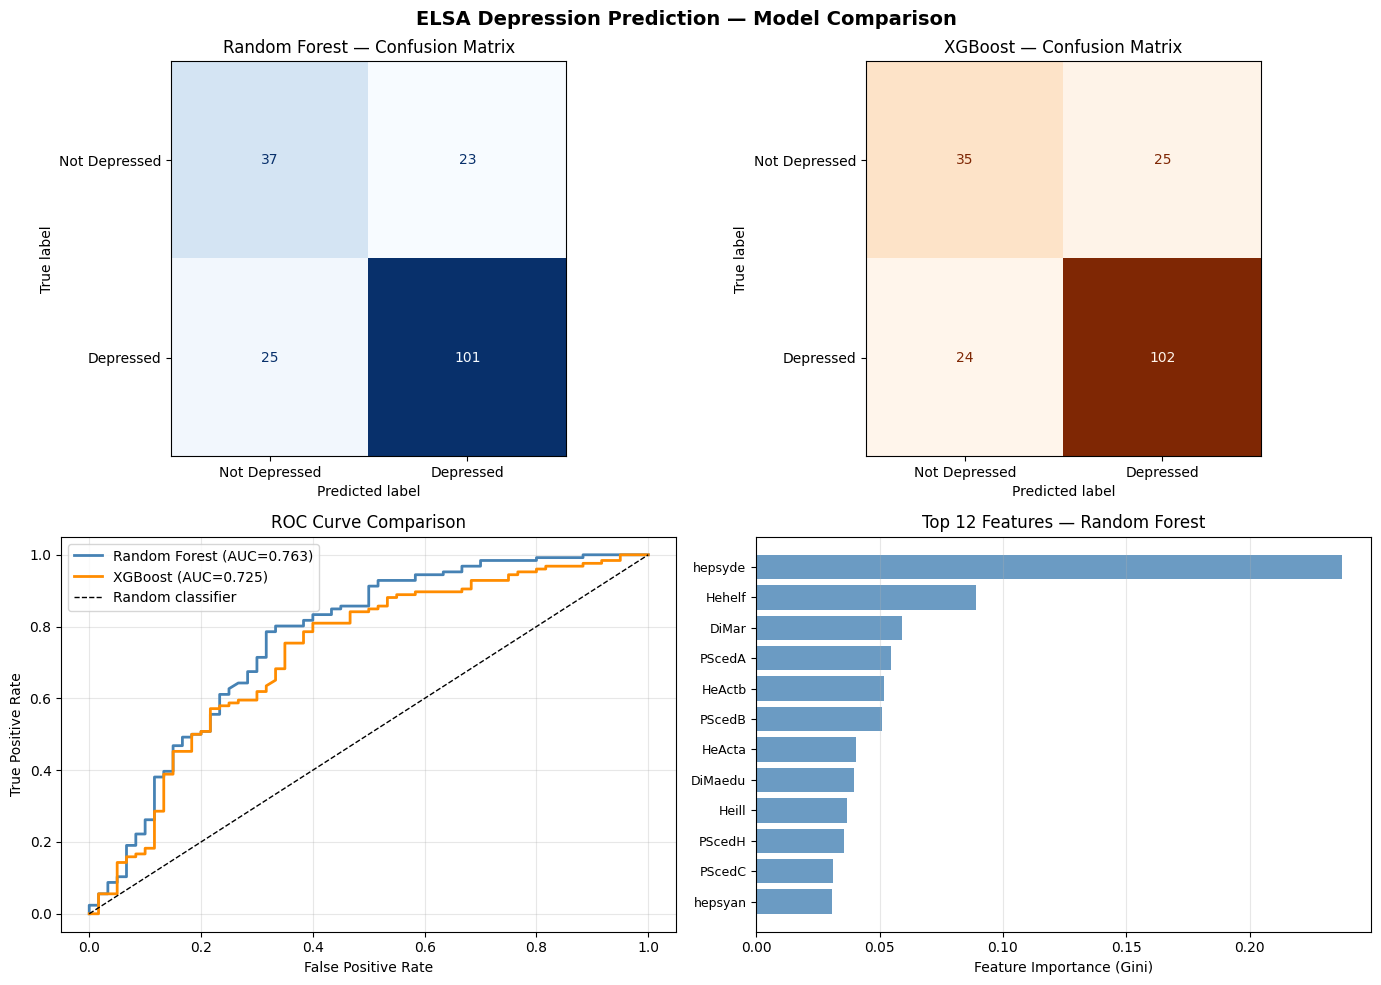

Plot saved as elsa_results.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ELSA Depression Prediction — Model Comparison', fontsize=14, fontweight='bold')

# --- Confusion Matrix: Random Forest ---
ConfusionMatrixDisplay(
    confusion_matrix(y_test, rf_pred),
    display_labels=['Not Depressed', 'Depressed']
).plot(ax=axes[0, 0], colorbar=False, cmap='Blues')
axes[0, 0].set_title('Random Forest — Confusion Matrix')

# --- Confusion Matrix: XGBoost ---
ConfusionMatrixDisplay(
    confusion_matrix(y_test, xgb_pred),
    display_labels=['Not Depressed', 'Depressed']
).plot(ax=axes[0, 1], colorbar=False, cmap='Oranges')
axes[0, 1].set_title('XGBoost — Confusion Matrix')

# --- ROC Curve: Both models ---
for prob, label, color, auc in [
    (rf_prob,  'Random Forest', 'steelblue', rf_auc),
    (xgb_prob, 'XGBoost',       'darkorange', xgb_auc),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[1, 0].plot(fpr, tpr, lw=2, label=f'{label} (AUC={auc:.3f})', color=color)

axes[1, 0].plot([0,1],[0,1],'k--', lw=1, label='Random classifier')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curve Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# --- Feature Importance: Random Forest ---
rf_model = rf_pipeline.named_steps['model']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:12]

axes[1, 1].barh(
    range(len(indices)),
    importances[indices][::-1],
    color='steelblue', alpha=0.8
)
axes[1, 1].set_yticks(range(len(indices)))
axes[1, 1].set_yticklabels([FEATURE_COLS[i] for i in indices][::-1], fontsize=9)
axes[1, 1].set_xlabel('Feature Importance (Gini)')
axes[1, 1].set_title('Top 12 Features — Random Forest')
axes[1, 1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('elsa_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as elsa_results.png')

## Cell 11 — Feature Importance: XGBoost

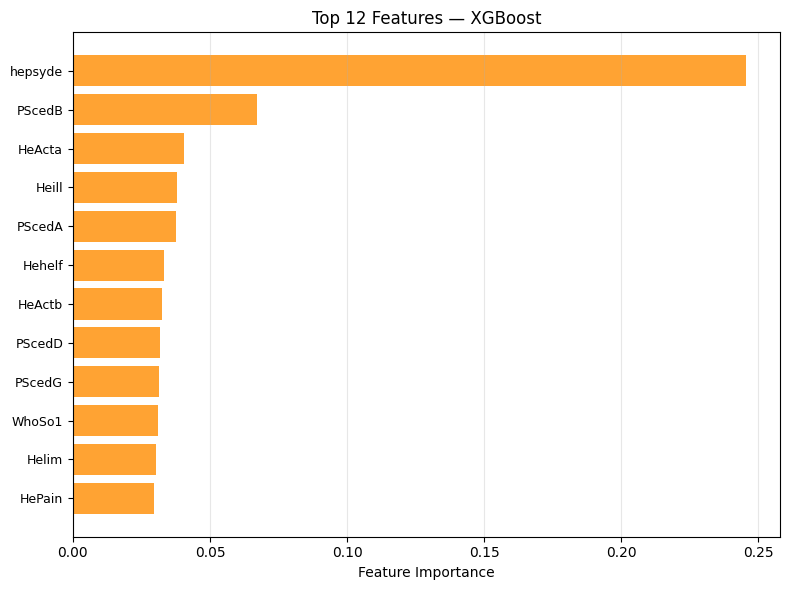

In [11]:
xgb_model = xgb_pipeline.named_steps['model']
xgb_importances = xgb_model.feature_importances_
xgb_indices = np.argsort(xgb_importances)[::-1][:12]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    range(len(xgb_indices)),
    xgb_importances[xgb_indices][::-1],
    color='darkorange', alpha=0.8
)
ax.set_yticks(range(len(xgb_indices)))
ax.set_yticklabels([FEATURE_COLS[i] for i in xgb_indices][::-1], fontsize=9)
ax.set_xlabel('Feature Importance')
ax.set_title('Top 12 Features — XGBoost')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('elsa_xgb_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 12 — Summary Table

In [12]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy':  [accuracy_score(y_test, rf_pred),  accuracy_score(y_test, xgb_pred)],
    'Precision': [precision_score(y_test, rf_pred), precision_score(y_test, xgb_pred)],
    'Recall':    [recall_score(y_test, rf_pred),    recall_score(y_test, xgb_pred)],
    'F1 Score':  [f1_score(y_test, rf_pred),        f1_score(y_test, xgb_pred)],
    'ROC-AUC':   [rf_auc,                           xgb_auc],
    'CV AUC (mean)': [rf_cv.mean(),                 xgb_cv.mean()],
}).round(3)

results = results.set_index('Model')
print(results.to_string())
results

               Accuracy  Precision  Recall  F1 Score  ROC-AUC  CV AUC (mean)
Model                                                                       
Random Forest     0.742      0.815   0.802     0.808    0.763          0.734
XGBoost           0.737      0.803   0.810     0.806    0.725          0.693


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV AUC (mean)
Model,,,,,,
Random Forest,0.742,0.815,0.802,0.808,0.763,0.734
XGBoost,0.737,0.803,0.810,0.806,0.725,0.693
